# ECG → R-Peaks → RR Pipeline
---
## Goal

In the previous notebook (`02_hrv_pipeline.ipynb`), I completed all *data structuring* tasks:

- Label distributions  
- Emotion timelines  
- `subject_summary.csv`  
- `timeline_table.csv` (Innovation #1)

This notebook begins the *signal processing* phase of Echo.

This part's goals are:

1. Load raw ECG signal for S2  
2. Clean ECG using NeuroKit  
3. Detect R-peaks  
4. Visualize ECG segments (manual QC)  
5. Compute RR intervals  
6. Compute instantaneous HR  
7. Save output as `rr_S2.csv`  


---
## 1. Set up

Here I import libraries, configure paths, and load the helper function for reading WESAD subjects.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import neurokit2 as nk
from pathlib import Path
import os
import pickle

# Set paths
data_path = Path("../data/raw/WESAD")
results_path = Path("../results")
results_path.mkdir(exist_ok=True)     # Create the results folder if it does not already exist

# Load subject function
# This function 1) builds the path to the subject folder
#               2) searches for a .pkl file inside it
#               3) loads the pickle file
def load_subject(subj):
    folder = data_path / subj

    pkl_files = list(folder.glob("*.pkl"))
    if not pkl_files:
        raise FileNotFoundError(f"No .pkl file found in folder {folder}")

    file_path = pkl_files[0]
    print("Loading:", file_path)

    # using latin1 to avoid encoding issues
    with open(file_path, "rb") as f:
        data = pickle.load(f, encoding="latin1")
    return data

print("Data path:", data_path)
print("Saving results to:", results_path)

Data path: ../data/raw/WESAD
Saving results to: ../results


---
## 2. Load Subject S2 ECG

In [ ]:
subj = "S2"
data = load_subject(subj)

ecg = data["signal"]["chest"]["ECG"]
fs = 700   # 700 is WESAD chest sampling rate

print("ECG length:", len(ecg))   # ECG length is the number of samples recorded in the ECG signal
print("Sampling rate:", fs, "Hz") # ECG length / fs = duration in seconds

Loading: ../data/raw/WESAD/S2/S2.pkl
ECG length: 4255300
Sampling rate: 700 Hz


---
## 3. Clean ECG

Raw ECG recorded from wearable sensors like the WESAD chest device contains several types of noise such as muscle tension, slow drift caused by breathing or body movement, 50/60 Hz electrical noise etc. 

So the purpose here to clean ECG is to reomve or at least reduce these components, leaving a signal where R-peaks are sharp and clearly visible. And that makes RR intervals become more accurate and the calculations of HRV features such as RMSSD, SDNN, pNN50, HF/LF, etc. easier.

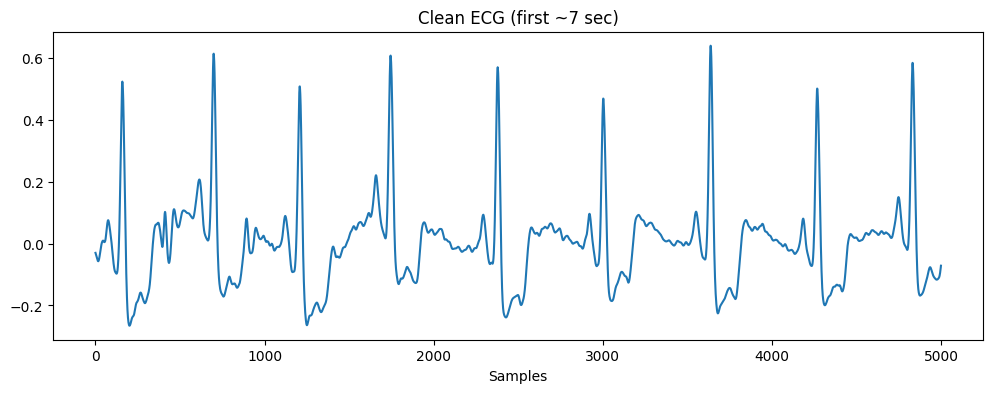

In [ ]:
# nk.ecg_clean applies a scientifically validated ECG preprocessing pipeline

# NeuroKit2 (nk) is a signal processing library designed for research in affective computing, psychophysiology, and BCI.
# It provides cleaning methods that preserve true cardiac morphology while removing noise.
ecg_clean = nk.ecg_clean(ecg, sampling_rate=fs, method="neurokit")

plt.figure(figsize=(12,4))
plt.plot(ecg_clean[:5000])
plt.title("Clean ECG (first ~7 sec)")  # This is because the full thing is about 4 million samples long. It would be very slow to plot all of it.
plt.xlabel("Samples")
plt.show()

---
## 4. Detect R-Peaks

ECG has millions of samples because it is sampled at 700 Hz, but R-peaks are sparse because each peak represents one heartbeat. For a 101-minute recording, we expect around 7000~8000 heartbeats. Detecting R-peaks is essential because all HRV features come from RR intervals.

In [6]:
peaks, info = nk.ecg_peaks(ecg_clean, sampling_rate=fs)
r_peaks = info["ECG_R_Peaks"]

print("Number of detected R-peaks:", len(r_peaks))

Number of detected R-peaks: 7250


---
## 5. Visualize ECG Segments (Quality Control)

ECG segment is a short slice of ECG signal. It allows us to inspect the signal in a manageable chunk. For example, a 10-second segment starting at 200 sec refers to samples 200s–210s.

Quality control means visually checking the signal in HRV and physiological signal research. 

### Helper function

In [11]:
def plot_ecg_segment(ecg_clean, r_peaks, fs, start_sec, duration=10):
    start = int(start_sec * fs)
    end = start + duration * fs
    
    segment = ecg_clean[start:end]
    t = np.arange(len(segment)) / fs
    
    # convert to numpy array so subtraction works
    rseg = np.array([p for p in r_peaks if start <= p < end])
    rseg_t = (rseg - start) / fs
    
    plt.figure(figsize=(12,4))
    plt.plot(t, segment, label="Clean ECG")
    if len(rseg) > 0:
        plt.scatter(rseg_t, segment[rseg - start], c="red", s=40, label="R-peaks")
    plt.title(f"ECG Segment: {start_sec}s – {start_sec + duration}s")
    plt.xlabel("Time (sec)")
    plt.legend()
    plt.show()

### Plot segments

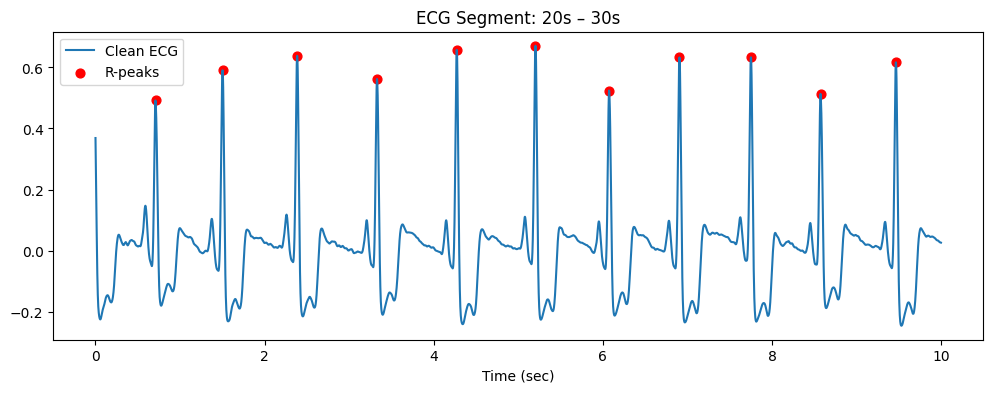

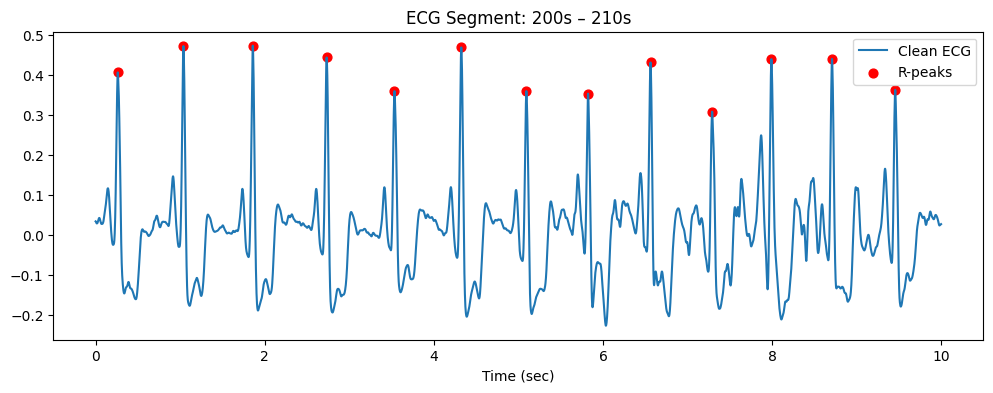

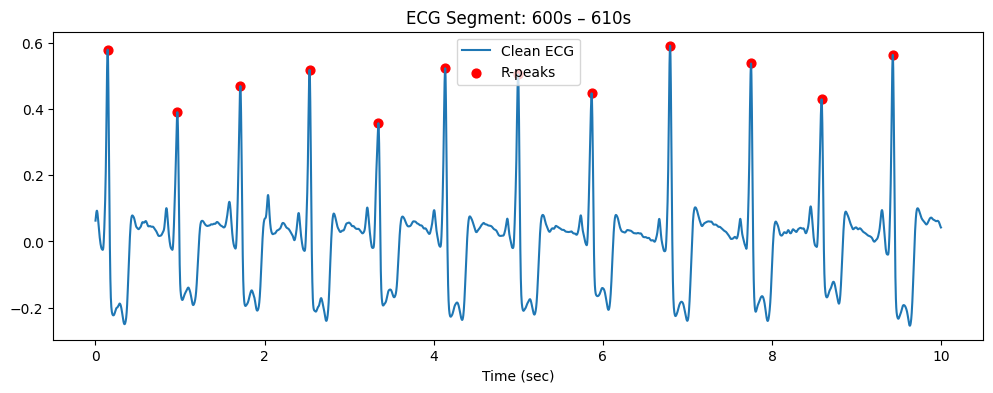

In [12]:
plot_ecg_segment(ecg_clean, r_peaks, fs, start_sec=20)
plot_ecg_segment(ecg_clean, r_peaks, fs, start_sec=200)
plot_ecg_segment(ecg_clean, r_peaks, fs, start_sec=600)

---
## 6. Build `rr_S2.csv` (RR Intervals + Heart Rate)

The goal of this step is to convert the detected R-peaks into meaningful physiological measurements and save them as a dataset ready for analysis. 

- RR intervals — the time between consecutive heartbeats
- heart rate HR — the number of beats per minute
- timestamp - indicatation of when each RR interval occure

In [ ]:
rr_samples = np.diff(r_peaks)      # rr_samples[i] = r_peaks[i+1] - r_peaks[i]      
rr_sec = rr_samples / fs           # Convert to seconds
hr_bpm = 60 / rr_sec               # Heart rate in beats per minute
time_sec = r_peaks[1:] / fs        # This places each RR/HR measurement at the moment it occurred

df_rr = pd.DataFrame({
    "time_sec": time_sec,
    "RR_sec": rr_sec,
    "HR_bpm": hr_bpm
})

output_file = results_path / "rr_S2.csv"
df_rr.to_csv(output_file, index=False)

df_rr.head()

,time_sec,RR_sec,HR_bpm
0,1.725714,0.727143,82.514735
1,2.492857,0.767143,78.212291
2,3.397143,0.904286,66.350711
3,4.288571,0.891429,67.307692
4,5.195714,0.907143,66.141732
